### Create SMET Forcing Files from Met Station Data (filled with HRRR-AK): Point Simulation at the Tram

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

## Load Tram Data: Cleaned in `1_clean_met_tram_synoptic.ipynb'

In [3]:
# open observations
# file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
file = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  # should really replace this with the WY2026 data once I fix that...
ds_met = xr.open_dataset(file)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
ds_met = ds_met.sel(time=slice("2019-10-01T05:00:00", "2025-09-30T05:00:00"))
ds_met


<xarray.Dataset> Size: 3MB
Dimensions:           (time: 44742)
Coordinates:
  * time              (time) datetime64[ns] 358kB 2019-10-01T05:00:00 ... 202...
Data variables:
    temp              (time) float64 358kB ...
    rh                (time) float64 358kB ...
    hs                (time) float64 358kB ...
    solar_rad         (time) float64 358kB ...
    precip_accum      (time) float64 358kB ...
    precip_rate       (time) float64 358kB ...
    precip_accum_1hr  (time) float64 358kB ...

In [4]:
# convert temp to K for comparison with HRRR-AK data
ds_met['temp'] = ds_met['temp'] + 273.15

In [5]:
# print the first few timesteps of the ds 
ds_met.time.values[:10]

array(['2019-10-01T05:00:00.000000000', '2019-10-01T06:00:00.000000000',
       '2019-10-01T07:00:00.000000000', '2019-10-01T08:00:00.000000000',
       '2019-10-01T09:00:00.000000000', '2019-10-01T10:00:00.000000000',
       '2019-10-01T11:00:00.000000000', '2019-10-01T12:00:00.000000000',
       '2019-10-01T13:00:00.000000000', '2019-10-01T14:00:00.000000000'],
      dtype='datetime64[ns]')

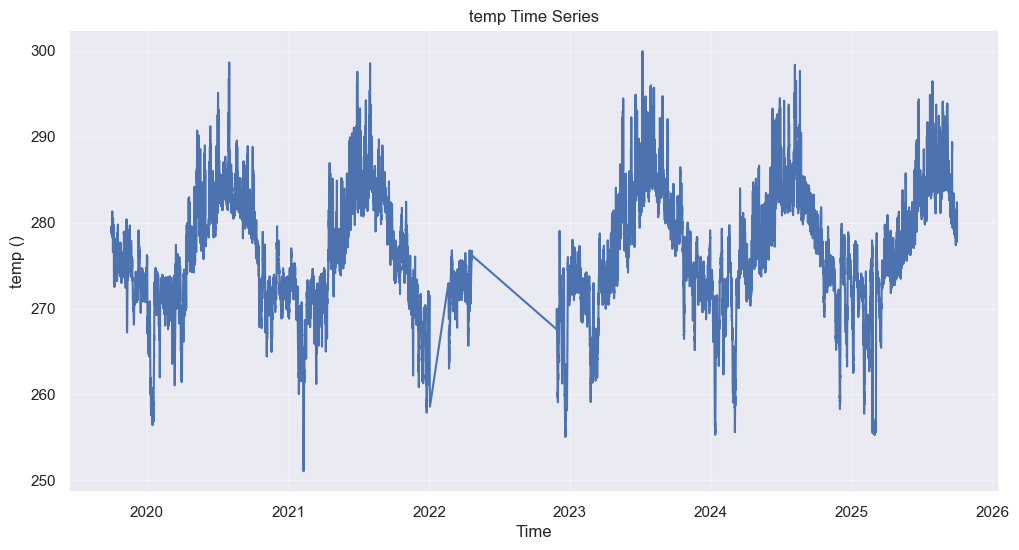

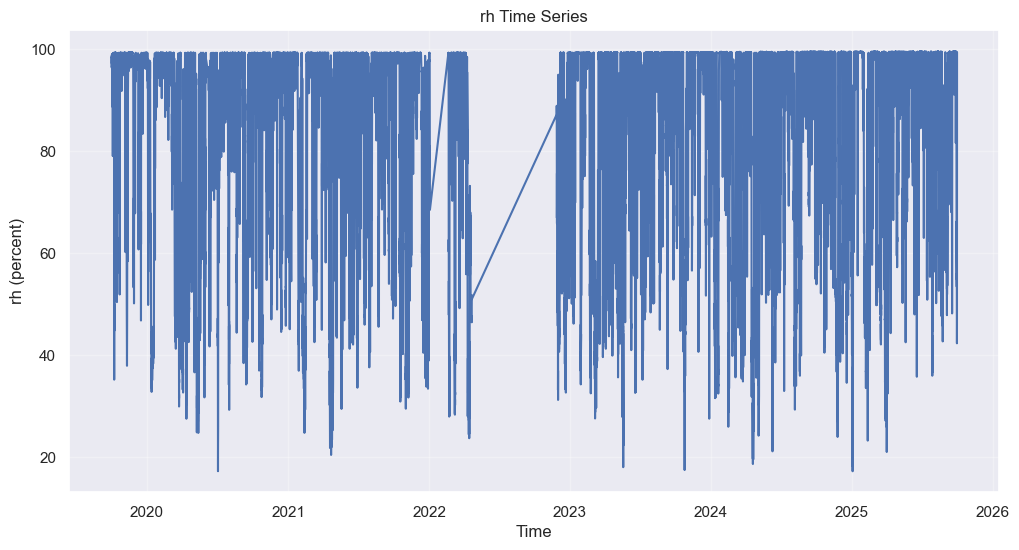

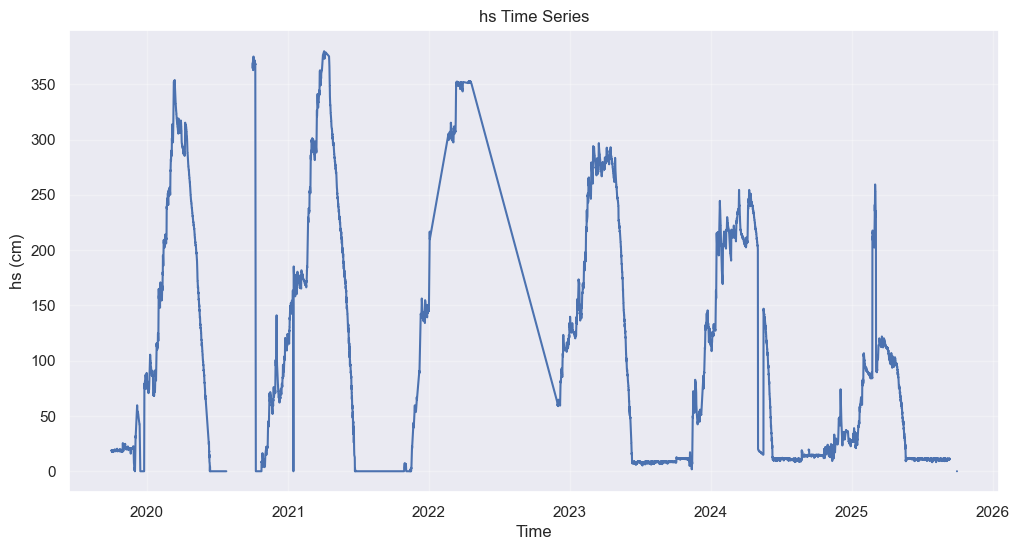

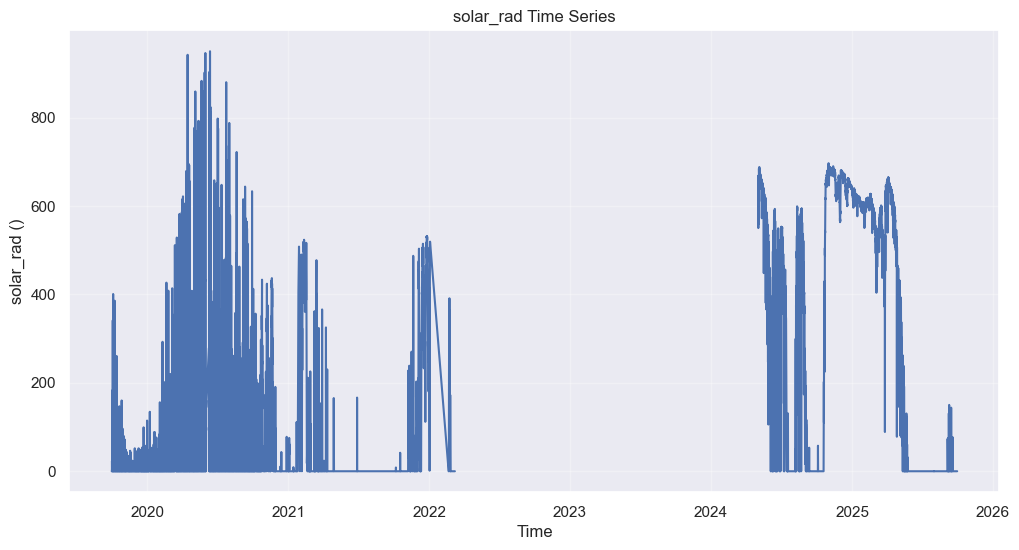

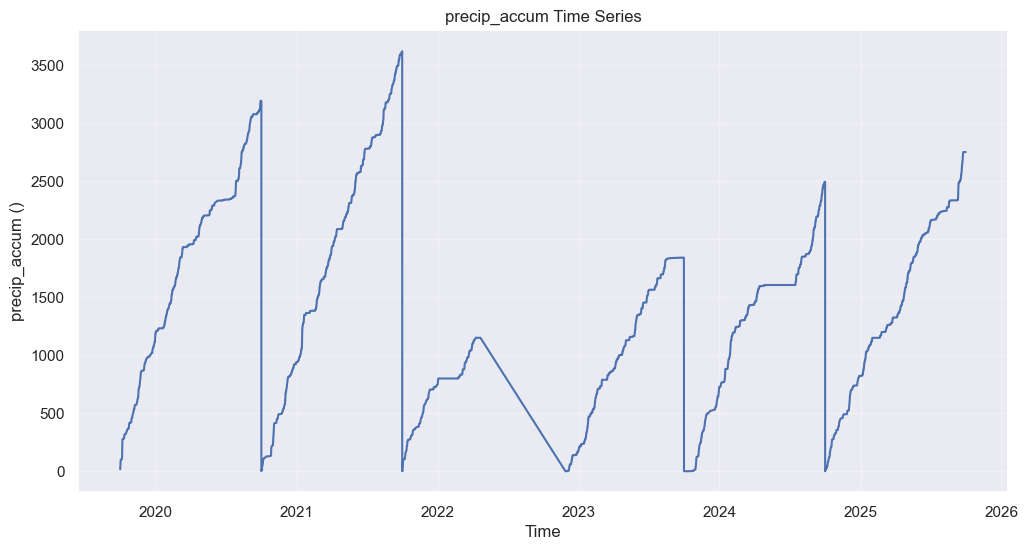

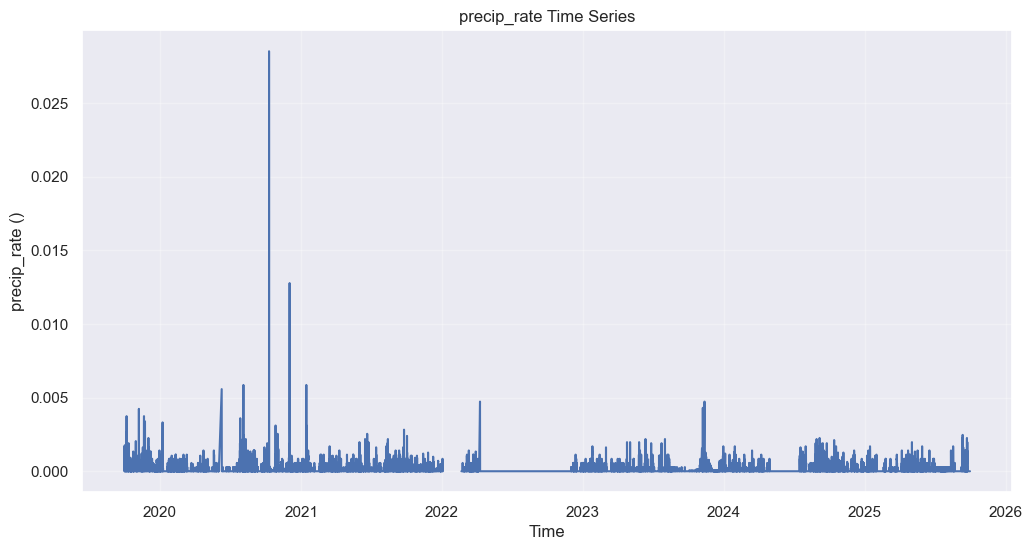

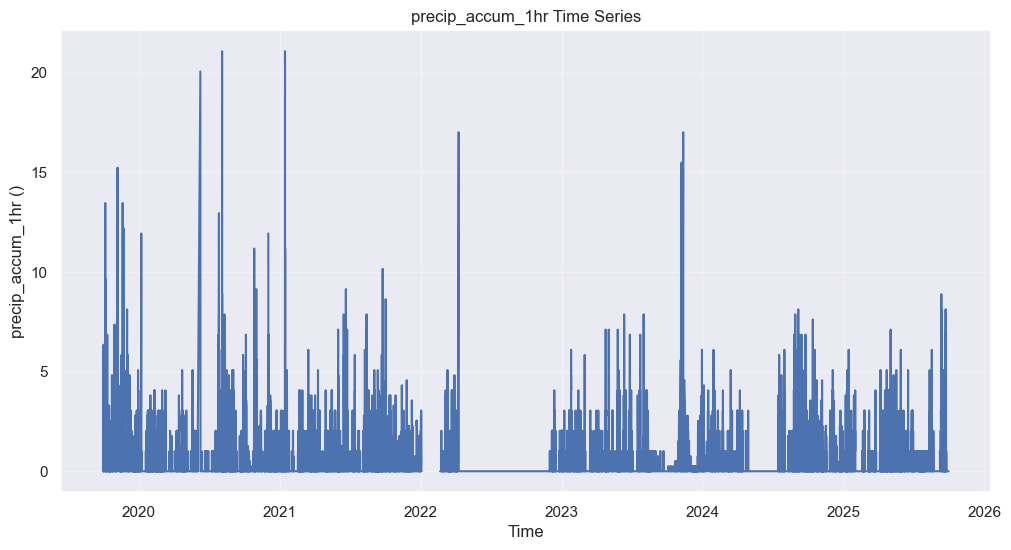

In [6]:
# plot all the variables to see what we have and how they look
for var in ds_met.data_vars:
    plt.figure()
    ds_met[var].plot()
    plt.title(f"{var} Time Series")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({ds_met[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()
    

We should not need much cleaning here since we did it largely in script 1...

_________________________________________________________________

## Load the HRRR-AK Dataset

In [7]:
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc"
ds_hrrr = xr.open_dataset(input_file)
ds_hrrr.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

# and clip to WY2020,2021,2022 
ds_hrrr = ds_hrrr.sel(time=slice("2019-10-01T05:00:00", "2025-09-30T05:00:00"))
ds_hrrr

<xarray.Dataset> Size: 13MB
Dimensions:       (time: 52584)
Coordinates:
    valid_time    (time) datetime64[ns] 421kB ...
    step          (time) timedelta64[ns] 421kB ...
  * time          (time) datetime64[ns] 421kB 2019-10-01T05:00:00 ... 2025-09...
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time) float64 421kB ...
    pressure      (time) float64 421kB ...
    orog          (time) float64 421kB ...
    temp_surface  (time) float64 421kB ...
    swe           (time) float64 421kB ...
    snowdepth     (time) float64 421kB ...
    ...            ...
    suswrf        (time) float64 421kB ...
    sulwrf        (time) float64 421kB ...
    wind          (time) float64 421kB ...
    wind_dir      (time) float64 421kB ...
    veg           (time) float64 421kB ...
    lai           (time) float64 421kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       tram
    original_lat:    58.2971
    original_lon:    -134.386
    utm_x:           535991.6505796042
    utm_y:           6461952.074115438

In [8]:
# print the first few timesteps of the ds 
ds_hrrr.time.values[:10]

array(['2019-10-01T05:00:00.000000000', '2019-10-01T06:00:00.000000000',
       '2019-10-01T07:00:00.000000000', '2019-10-01T08:00:00.000000000',
       '2019-10-01T09:00:00.000000000', '2019-10-01T10:00:00.000000000',
       '2019-10-01T11:00:00.000000000', '2019-10-01T12:00:00.000000000',
       '2019-10-01T13:00:00.000000000', '2019-10-01T14:00:00.000000000'],
      dtype='datetime64[ns]')

## Clean up hourly timeseries to merge the datasets later

In [34]:
# # check that both datasets have the same time range and frequency
# print("Met Dataset:")
# print(f"Start: {ds_met.time.values[0]}, End: {ds_met.time.values[-1]}, Frequency: {pd.infer_freq(ds_met.time.values)}")
# print("\nHRRR AK Dataset:")
# print(f"Start: {ds_hrrr.time.values[0]}, End: {ds_hrrr.time.values[-1]}, Frequency: {pd.infer_freq(ds_hrrr.time.values)}")

In [33]:
# # check that the hrrrr dataset is hourly and continuous (no missing timesteps)
# time_diffs = np.diff(ds_hrrr.time.values) / np.timedelta64(1, 'h')  # convert to hours
# missing_timesteps = np.where(time_diffs != 1)[0]
# if len(missing_timesteps) == 0:
#     print("HRRR-AK dataset is hourly and continuous with no missing timesteps.")
# else:
#     print(f"HRRR-AK dataset has {len(missing_timesteps)} missing timesteps at indices: {missing_timesteps}")

### Create a regular hourly time axis and insert NaN for missing hours (no mean or interpt)

In [30]:
# # Create continuous hourly time axis
# ds_met = (ds_met.resample(time='1h').asfreq()) # this creates a regular hourly time axis and inserts nan for missing hours 
# ds_hrrr = (ds_hrrr.resample(time='1h').asfreq()) 

but I should not have to do this because I already made a forcing dataset with the HRRR-AK data and it ran. 

So the issue must be with the datetime structure of the met...

In [31]:
# # check that both datasets have the same time range and frequency
# print("Met Dataset:")
# print(f"Start: {ds_met.time.values[0]}, End: {ds_met.time.values[-1]}, Frequency: {pd.infer_freq(ds_met.time.values)}")
# print("\nHRRR AK Dataset:")
# print(f"Start: {ds_hrrr.time.values[0]}, End: {ds_hrrr.time.values[-1]}, Frequency: {pd.infer_freq(ds_hrrr.time.values)}")

In [32]:
# # check that the hrrrr dataset is hourly and continuous (no missing timesteps)
# time_diffs = np.diff(ds_hrrr.time.values) / np.timedelta64(1, 'h')  # convert to hours
# missing_timesteps = np.where(time_diffs != 1)[0]
# if len(missing_timesteps) == 0:
#     print("HRRR-AK dataset is hourly and continuous with no missing timesteps.")
# else:
#     print(f"HRRR-AK dataset has {len(missing_timesteps)} missing timesteps at indices: {missing_timesteps}")

Compare Precipiation, 

In [14]:
ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

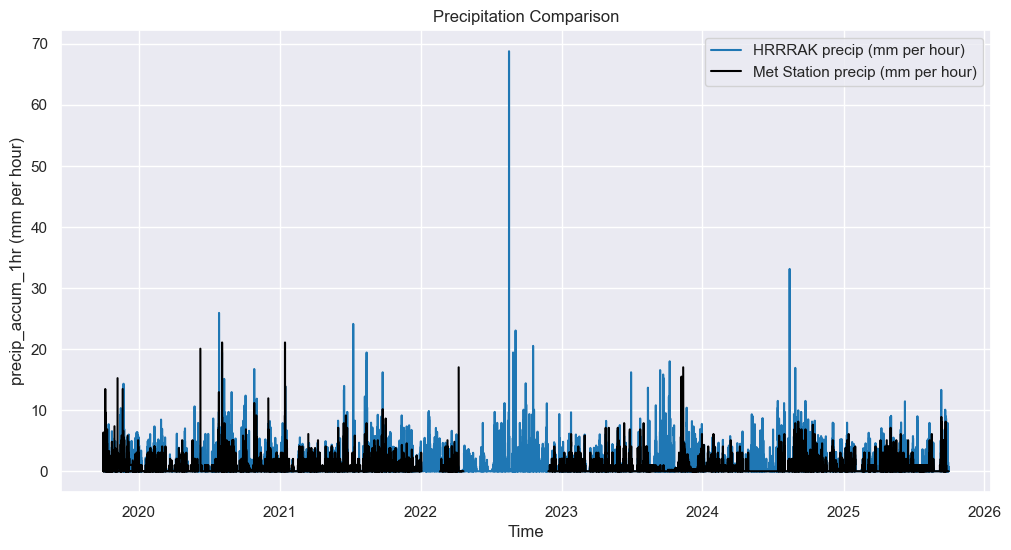

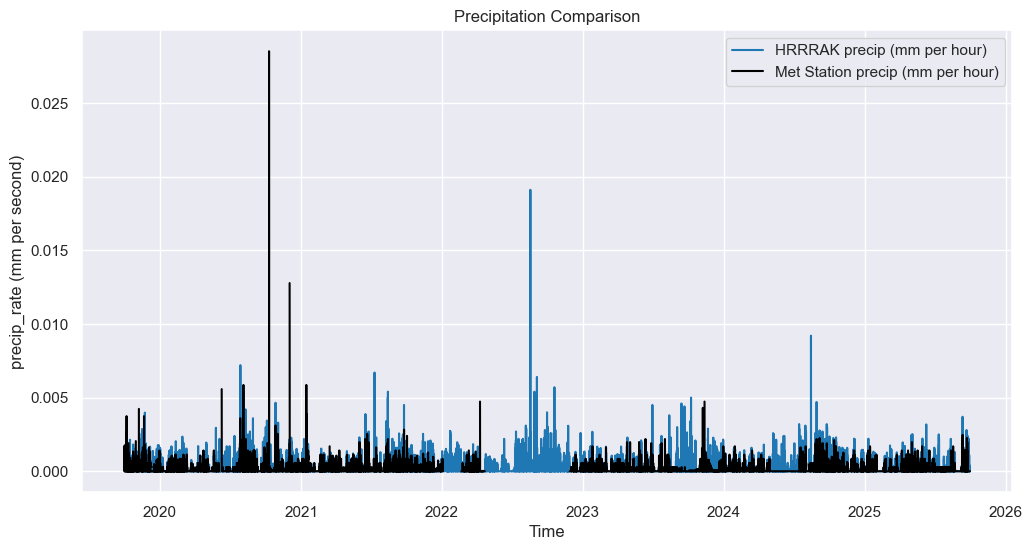

In [15]:
# compare precip 
ds_hrrr['precip_accum_1hr'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
ds_met["precip_accum_1hr"].plot(label="Met Station precip (mm per hour)", color='black')
plt.title("Precipitation Comparison")
plt.xlabel("Time")
plt.ylabel("precip_accum_1hr (mm per hour)")
plt.legend()
plt.show()

# compare precip 
ds_hrrr['precip_rate'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
ds_met["precip_rate"].plot(label="Met Station precip (mm per hour)", color='black')
plt.title("Precipitation Comparison")
plt.xlabel("Time")
plt.ylabel("precip_rate (mm per second)")
plt.legend()
plt.show()

In [16]:
# check for any nans in the hrrr precip_accum_1hr data 
print("Number of NaNs in HRRR-AK precip_accum_1hr:", np.isnan(ds_hrrr['precip_accum_1hr']).sum().item())

Number of NaNs in HRRR-AK precip_accum_1hr: 1


In [17]:
# remove that large precip_accum_1hr spike in the hrrr data and change it to 0 for now 
ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_accum_1hr'].where(ds_hrrr['precip_accum_1hr'] < 30, 0)

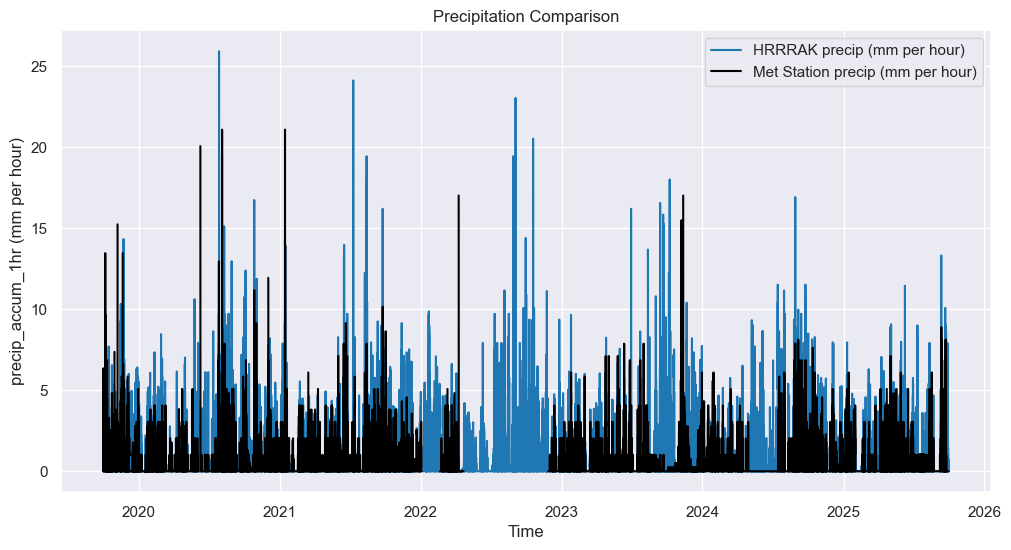

In [18]:
# compare precip 
ds_hrrr['precip_accum_1hr'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
ds_met["precip_accum_1hr"].plot(label="Met Station precip (mm per hour)", color='black')
plt.title("Precipitation Comparison")
plt.xlabel("Time")
plt.ylabel("precip_accum_1hr (mm per hour)")
plt.legend()
plt.show()

In [19]:
# now check if there are any negative precip values 
print("Number of negative values in HRRR-AK precip_accum_1hr:", (ds_hrrr['precip_accum_1hr'] < 0).sum().item())
print("Number of negative values in HRRR-AK precip_accum_1hr:", (ds_met['precip_accum_1hr'] < 0).sum().item())

Number of negative values in HRRR-AK precip_accum_1hr: 0
Number of negative values in HRRR-AK precip_accum_1hr: 0


Compare accumulated precip, 

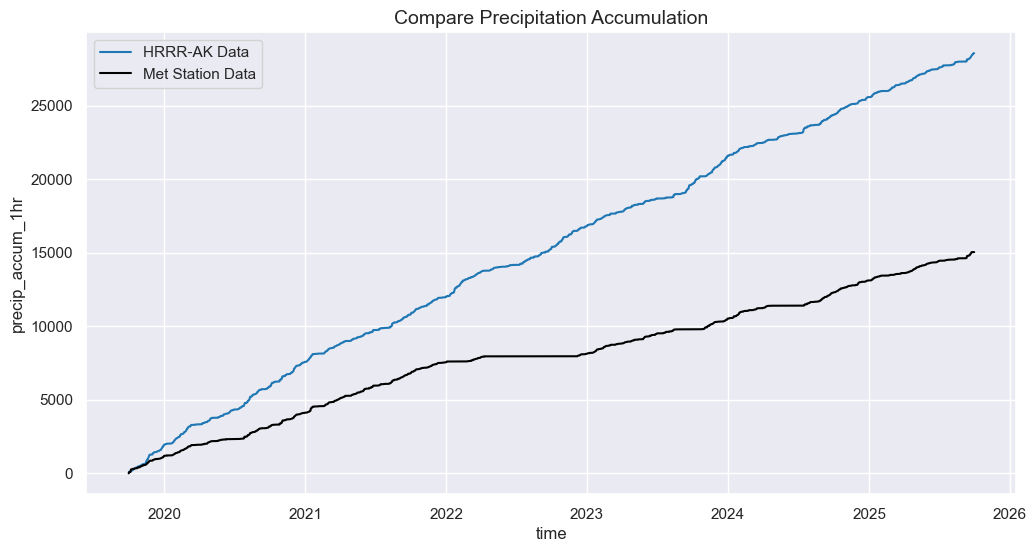

In [20]:
ds_hrrr['precip_accum_1hr'].cumsum().plot(label='HRRR-AK Data', color='tab:blue')

# now divide precip accum by 2 to compare 
# (ds_hrrr['precip_accum_1hr'].cumsum() / 1.3).plot(label='HRRR-AK Data Scale (Divide) by 1.3', color='tab:orange')
ds_met['precip_accum_1hr'].cumsum().plot(label='Met Station Data', color='black')

plt.title('Compare Precipitation Accumulation', fontsize=14)
plt.legend()
plt.show()

Air temperature, 

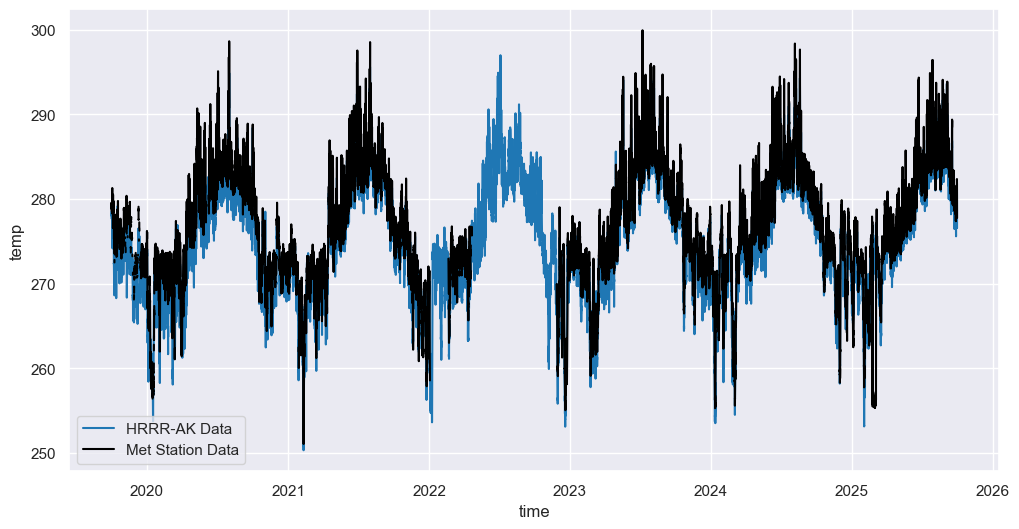

In [21]:
# compare temp
ds_hrrr.temp.plot(label='HRRR-AK Data', color='tab:blue')
ds_met.temp.plot(label='Met Station Data', color='black')

plt.legend()

Relative Humidity, 

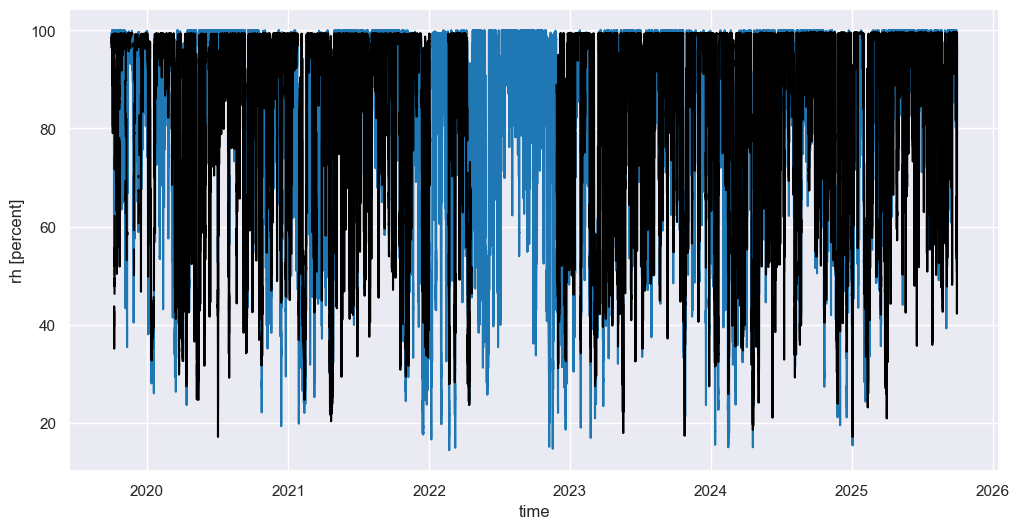

In [22]:
# compare rh 
ds_hrrr['rh'].plot(label='HRRR-AK Data', color='tab:blue')
ds_met['rh'].plot(label='Met Station Data', color='black')

# The Workflow Below, 

HRRR (NetCDF / xarray)\
   → your Python script\
   → SMET (ASCII)\
   → SNOWPACK


#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [23]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [24]:
from pathlib import Path
from pyproj import Transformer

In [25]:
# lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [26]:
# relate the variables, df_met is for the met station data 
ds_met = ds_met.copy()

# ds is for the HRRRAK data
ds_hrrrak = ds_hrrr.copy()

New Code, 


Original dataset ranges:
MET:  2019-10-01T05:00:00.000000000 -> 2025-09-30T05:00:00.000000000
HRRR: 2019-10-01T05:00:00.000000000 -> 2025-09-30T05:00:00.000000000

Coverage statistics:
MET precip valid fraction: 0.8507559189883046
HRRR precip valid fraction: 1.0

Fraction of timesteps using MET data:
TA: 0.8506988684986213
RH: 0.850851003137777
PSUM: 0.8507559189883046

Timesteps where PSUM differs from HRRR:
19369

SMET file written to:
/home/cassie/python/models/run_snowpack/sites/tram/input/met_hrrrak_tram_WY2020-WY2025.smet


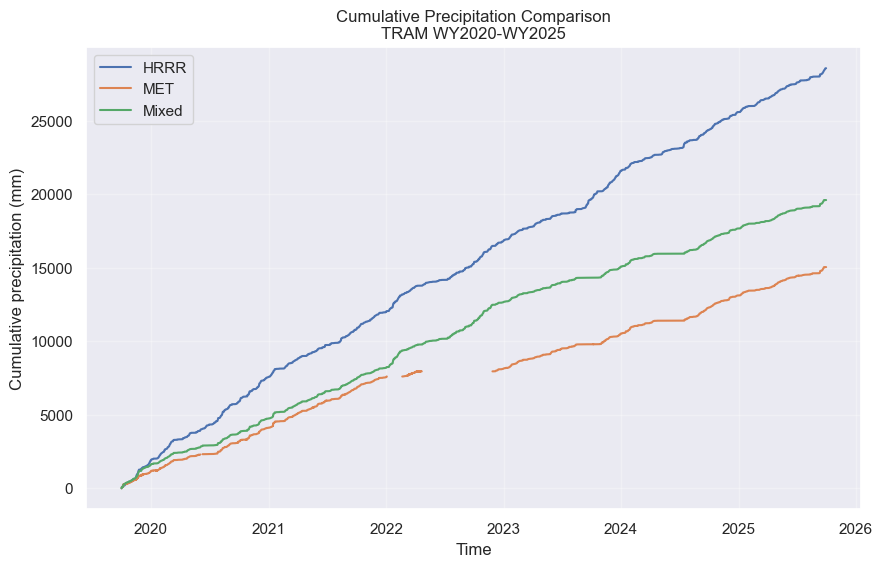

In [29]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================

start_time = '2019-10-01T05:00'
end_time   = '2025-09-30T05:00'

TIMESTEP = "1h"

OUTFILE = Path(
    "/home/cassie/python/models/run_snowpack/sites/tram/input/"
    "/met_hrrrak_WY2020-WY2025/met_hrrrak_tram_WY2020-WY2025.smet"
)

STATION_ID   = "met_hrrrak_tram_WY2020-WY2025"
STATION_NAME = "Met Station and HRRR-AK TRAM Point Forcing"

LAT  = lat_tram
LON  = lon_tram
ELEV = elevation_tram

EPSG   = 32608
TZ     = 0
NODATA = -999

# ============================================================
# SLICE TO COMMON TIME RANGE
# ============================================================

ds_met = ds_met.sel(time=slice(start_time, end_time))
ds_hrrrak = ds_hrrrak.sel(time=slice(start_time, end_time))

print("\nOriginal dataset ranges:")
print(f"MET:  {ds_met.time.min().values} -> {ds_met.time.max().values}")
print(f"HRRR: {ds_hrrrak.time.min().values} -> {ds_hrrrak.time.max().values}")

# ============================================================
# SORT TIME AXES
# ============================================================

# Always sort before resampling/reindexing
ds_met = ds_met.sortby("time")
ds_hrrrak = ds_hrrrak.sortby("time")

# ============================================================
# CREATE CONTINUOUS HOURLY TIME AXES
# ============================================================

# IMPORTANT:
# asfreq() DOES NOT average/interpolate data.
# It simply creates a regular hourly time axis and inserts NaNs
# where timestamps are missing.
#
# This is MUCH safer for precipitation accumulation variables.

ds_met = ds_met.resample(time='1h').asfreq()
ds_hrrrak = ds_hrrrak.resample(time='1h').asfreq()

# ============================================================
# ALIGN MET DATA TO HRRR TIME AXIS
# ============================================================

# Use exact HRRR timestamps as the master time axis
# and reindex MET data onto it.
#
# IMPORTANT:
# reindex() does NOT interpolate or shift storms in time.
# Missing timestamps remain NaN.

ds_met = ds_met.reindex(time=ds_hrrrak.time)

# ============================================================
# UNIT CONVERSIONS
# ============================================================

# ---- Relative Humidity ----
# Convert both datasets to fraction [0-1]

ds_met["rh"] = ds_met["rh"] / 100.0
ds_hrrrak["rh"] = ds_hrrrak["rh"] / 100.0

# ---- Temperature ----
# Ensure both are in Kelvin.
#
# Uncomment if MET temperature is in Celsius:
#
# ds_met["temp"] = ds_met["temp"] + 273.15

# ============================================================
# DIAGNOSTIC CHECKS
# ============================================================

print("\nCoverage statistics:")

print(
    "MET precip valid fraction:",
    float(ds_met["precip_accum_1hr"].notnull().mean())
)

print(
    "HRRR precip valid fraction:",
    float(ds_hrrrak["precip_accum_1hr"].notnull().mean())
)

# ============================================================
# CREATE COMBINED DATASET
# ============================================================

# combine_first() means:
#
# "Use ds_met values where available,
# otherwise fill with ds_hrrrak"
#
# EXACTLY what we want.

ds_combined = ds_met.combine_first(ds_hrrrak)

# ============================================================
# BUILD FINAL FORCING DATASET
# ============================================================

ds_filled = xr.Dataset(coords={"time": ds_hrrrak.time})

# ============================================================
# VARIABLES USING MET FIRST, THEN HRRR
# ============================================================

ds_filled["TA"] = ds_combined["temp"]
ds_filled["RH"] = ds_combined["rh"]
ds_filled["PSUM"] = ds_combined["precip_accum_1hr"]

# ============================================================
# VARIABLES ALWAYS FROM HRRR
# ============================================================

ds_filled["ISWR"] = ds_hrrrak["swrad"]
ds_filled["ILWR"] = ds_hrrrak["lwrad"]
ds_filled["PS"]   = ds_hrrrak["pressure"]

# ---- Wind speed and direction ----

u = ds_hrrrak["10u"]
v = ds_hrrrak["10v"]

ds_filled["VW"] = np.sqrt(u**2 + v**2)

# Meteorological wind direction
ds_filled["DW"] = (
    (270.0 - np.degrees(np.arctan2(v, u))) % 360.0
)

# ============================================================
# DIAGNOSTIC OUTPUT
# ============================================================

print("\nFraction of timesteps using MET data:")

print(
    "TA:",
    float(ds_met["temp"].notnull().mean())
)

print(
    "RH:",
    float(ds_met["rh"].notnull().mean())
)

print(
    "PSUM:",
    float(ds_met["precip_accum_1hr"].notnull().mean())
)

print("\nTimesteps where PSUM differs from HRRR:")

print(
    int(
        (ds_filled["PSUM"] != ds_hrrrak["precip_accum_1hr"]).sum()
    )
)

# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

df_smet = ds_filled.to_dataframe()

# ============================================================
# FINAL TIME HANDLING
# ============================================================

# Since data are ALREADY hourly,
# we avoid another resample().sum()/mean().
#
# This prevents accidental precipitation corruption.

df_smet = df_smet.asfreq(TIMESTEP)

# ============================================================
# REPLACE MISSING VALUES
# ============================================================

df_smet = df_smet.fillna(NODATA)

# ============================================================
# COORDINATE TRANSFORM
# ============================================================

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32608",
    always_xy=True
)

EASTING, NORTHING = transformer.transform(LON, LAT)

# ============================================================
# WRITE SMET FILE
# ============================================================

with open(OUTFILE, "w") as f:

    f.write("SMET 1.1 ASCII\n")

    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = MET filled with HRRR-AK\n")

    f.write(
        "fields           = "
        "timestamp TA RH VW DW ISWR ILWR PSUM PS\n"
    )

    f.write("[DATA]\n")

    for t, row in df_smet.iterrows():

        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} "
            f"{row.RH:6.3f} "
            f"{row.VW:6.2f} "
            f"{row.DW:6.1f} "
            f"{row.ISWR:8.1f} "
            f"{row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} "
            f"{row.PS:8.1f}\n"
        )

print(f"\nSMET file written to:\n{OUTFILE}")

# ============================================================
# PRECIPITATION COMPARISON PLOT
# ============================================================

plt.figure(figsize=(10, 6))

# HRRR precip
plt.plot(
    ds_hrrrak["precip_accum_1hr"].to_series().cumsum(),
    label="HRRR",
)

# MET precip
plt.plot(
    ds_met["precip_accum_1hr"].to_series().cumsum(),
    label="MET",
)

# Mixed precip
plt.plot(
    ds_filled["PSUM"].to_series().cumsum(),
    label="Mixed",
)

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")

plt.title(
    "Cumulative Precipitation Comparison\n"
    "TRAM WY2020-WY2025"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

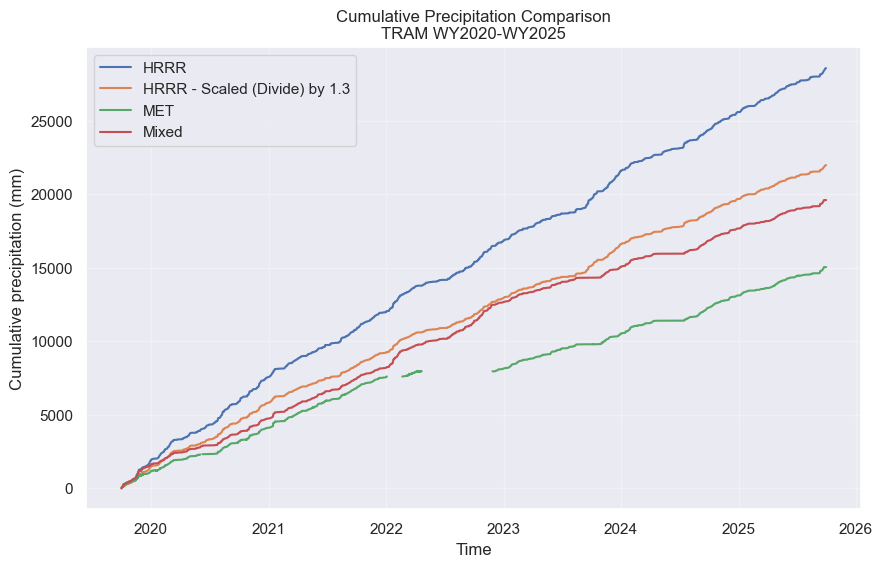

In [37]:
# ============================================================
# PRECIPITATION COMPARISON PLOT
# ============================================================

plt.figure(figsize=(10, 6))

# HRRR precip
plt.plot(
    ds_hrrrak["precip_accum_1hr"].to_series().cumsum(),
    label="HRRR",
)

# HRRR precip
plt.plot(
    ds_hrrrak["precip_accum_1hr"].to_series().cumsum()/1.3,
    label="HRRR - Scaled (Divide) by 1.3",
)

# MET precip
plt.plot(
    ds_met["precip_accum_1hr"].to_series().cumsum(),
    label="MET",
)

# Mixed precip
plt.plot(
    ds_filled["PSUM"].to_series().cumsum(),
    label="Mixed",
)

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")

plt.title(
    "Cumulative Precipitation Comparison\n"
    "TRAM WY2020-WY2025"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

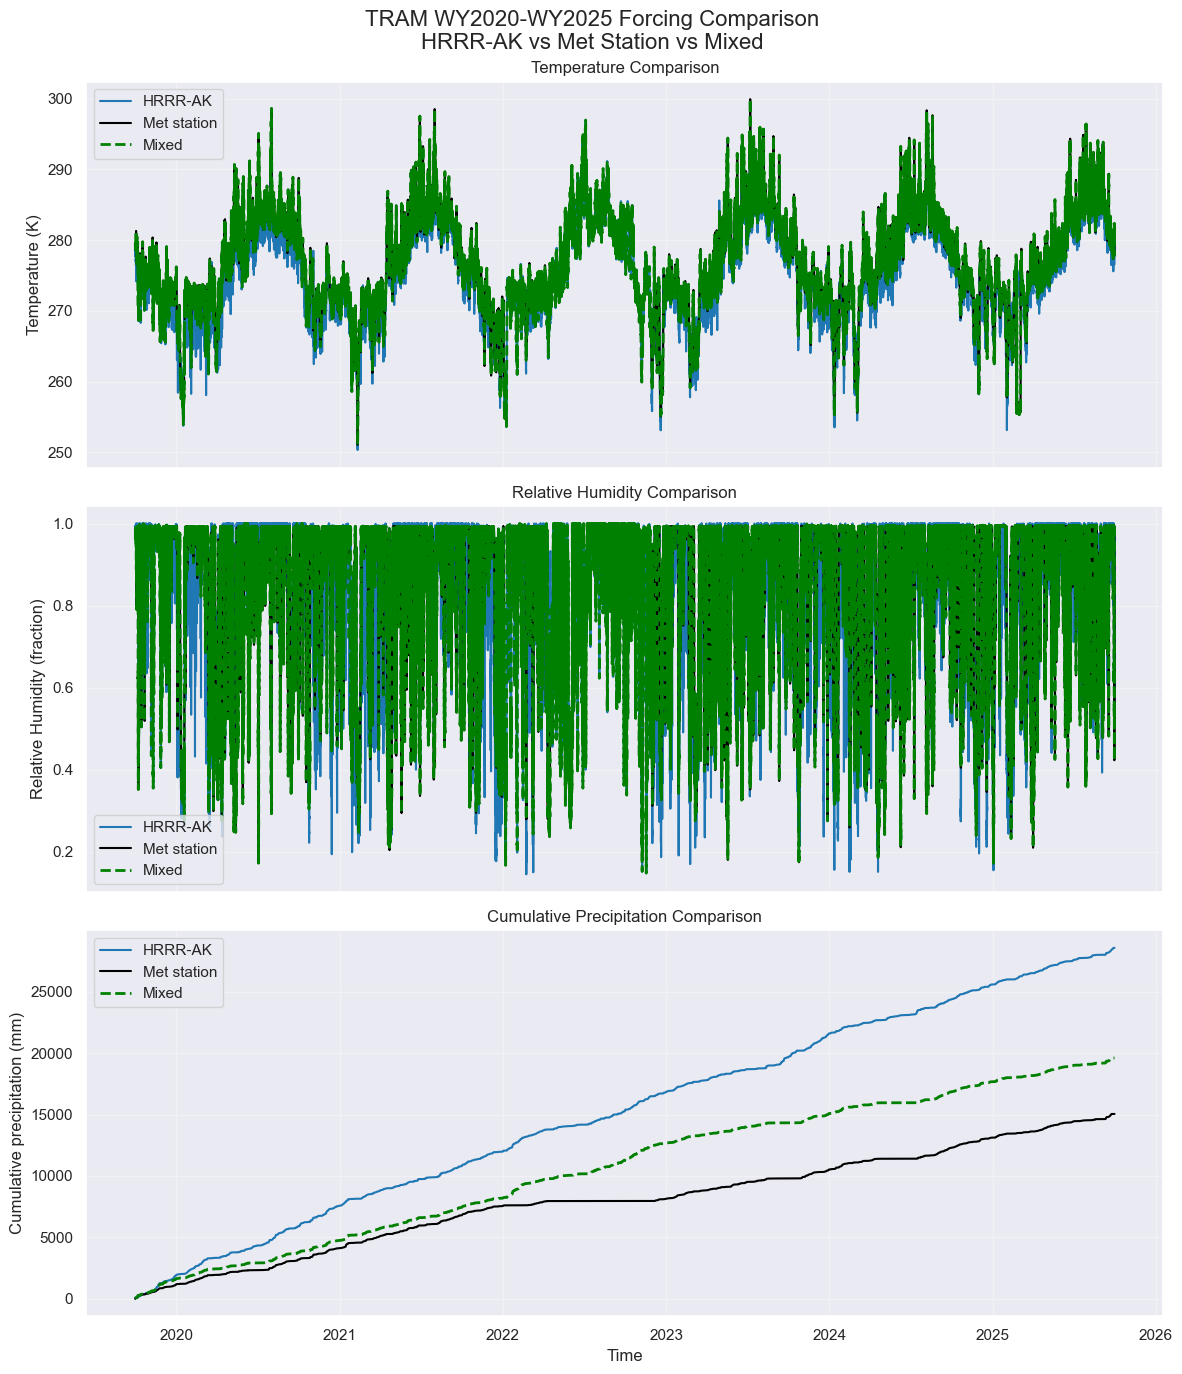

In [38]:
# ============================================================
# MULTI-VARIABLE COMPARISON PLOT
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14),
    sharex=True
)

# ============================================================
# TEMPERATURE
# ============================================================

ax = axes[0]

# All datasets already aligned and in Kelvin

ax.plot(
    ds_hrrrak["temp"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_met["temp"].to_series(),
    label="Met station",
    color="black"
)

ax.plot(
    ds_filled["TA"].to_series(),
    label="Mixed",
    color="green",
    linestyle="--",
    linewidth=2
)

ax.set_ylabel("Temperature (K)")
ax.set_title("Temperature Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# RELATIVE HUMIDITY
# ============================================================

ax = axes[1]

# RH already converted to fraction [0-1]

ax.plot(
    ds_hrrrak["rh"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_met["rh"].to_series(),
    label="Met station",
    color="black"
)

ax.plot(
    ds_filled["RH"].to_series(),
    label="Mixed",
    color="green",
    linestyle="--",
    linewidth=2
)

ax.set_ylabel("Relative Humidity (fraction)")
ax.set_title("Relative Humidity Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# PRECIPITATION
# ============================================================

ax = axes[2]

# Plot cumulative precipitation
# Skip NaNs before cumsum to avoid propagation

ax.plot(
    ds_hrrrak["precip_accum_1hr"]
    .fillna(0)
    .to_series()
    .cumsum(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_met["precip_accum_1hr"]
    .fillna(0)
    .to_series()
    .cumsum(),
    label="Met station",
    color="black"
)

ax.plot(
    ds_filled["PSUM"]
    .fillna(0)
    .to_series()
    .cumsum(),
    label="Mixed",
    color="green",
    linestyle="--",
    linewidth=2
)

ax.set_ylabel("Cumulative precipitation (mm)")
ax.set_title("Cumulative Precipitation Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# COMMON X-AXIS
# ============================================================

axes[-1].set_xlabel("Time")

plt.suptitle(
    "TRAM WY2020-WY2025 Forcing Comparison\n"
    "HRRR-AK vs Met Station vs Mixed",
    fontsize=16
)

plt.tight_layout()

plt.show()